In [1]:
#Algorithm - Autoregression (AR)

In [2]:
#1.IMPORT PANDAS LIBRARY

import pandas as pd
# import → keyword to load a full module
# pandas (module) → Python library for data manipulation and analysis
# as → keyword used to assign an alias
# pd → alias name assigned to the pandas module

# This line imports the pandas library (as pd) so its data-handling functions can be used in this notebook.

In [3]:
#2.IMPORT STOCK DATA FUNCTION AND DATETIME MODULE

from nsepy import get_history as gh
# from → keyword to import a specific part of a module
# nsepy (module) → Python library used to fetch NSE (National Stock Exchange) stock data
# import → keyword that loads the specified item into the notebook
# get_history → function from nsepy that retrieves historical stock price data
# as → keyword used to give an imported item an alias (shorter name)
# gh → alias name assigned to get_history for easier use

import datetime as dt
# import → keyword to load a full module
# datetime (module) → built-in Python module for handling dates and times
# as → keyword used to assign an alias
# dt → alias name assigned to the datetime module

# This code imports the get_history function (aliased as gh) from nsepy and the datetime module (aliased as dt), needed to fetch and work 
# with historical stock data.

In [4]:
#3.FETCH STOCK HISTORICAL DATA (using yfinance)

import yfinance as yf
# import → keyword to load a full module
# yfinance (module) → Python library used to fetch stock market data from Yahoo Finance
# as → keyword used to assign an alias
# yf → alias name assigned to the yfinance module

start = "2021-07-01"
# start → variable name storing the start date
# = → assignment operator
# "2021-07-01" → date string in YYYY-MM-DD format

end = "2022-01-28"
# end → variable name storing the end date
# = → assignment operator
# "2022-01-28" → date string in YYYY-MM-DD format

stk_data = yf.download("TCS.NS", start=start, end=end)
# stk_data → variable name storing the fetched stock data
# = → assignment operator
# yf.download(...) → calls the download function to fetch historical stock data
# "TCS.NS" → stock symbol with .NS suffix (required for NSE-listed stocks on Yahoo Finance)
# start=start → parameter passing the start date defined above
# end=end → parameter passing the end date defined above

stk_data.columns = stk_data.columns.get_level_values(0)
# stk_data.columns → the current column labels of the DataFrame (returned as a MultiIndex by yfinance)
# = → assignment operator, reassigns the columns with a new value
# stk_data.columns.get_level_values(0) → extracts only the first level of the MultiIndex (e.g. 'Close', 'Open'), dropping the ticker-name level

# This code fetches historical stock price data for TCS (NSE) between 1 July 2021 and 28 January 2022 using yfinance, and flattens the 
# column names to simple labels.

[*********************100%***********************]  1 of 1 completed


In [5]:
#4.DISPLAY DATASET

stk_data
# stk_data → the DataFrame variable holding the fetched stock data
# (no method/operator) → simply displays the DataFrame's contents directly in the notebook output

# This code prints out the full stk_data DataFrame — showing all the fetched stock's rows and columns (Open, High, Low, Close, Volume, etc.).

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-07-01,2896.435547,2914.205090,2888.504348,2910.737862,990310
2021-07-02,2882.522461,2894.874457,2856.301557,2887.333281,1682274
2021-07-05,2878.665771,2924.606538,2862.196440,2896.868717,1972858
2021-07-06,2827.783936,2884.733101,2822.409776,2871.730999,2159420
2021-07-07,2838.749023,2845.466776,2809.841142,2838.792406,2640710
...,...,...,...,...,...
2022-01-20,3336.348633,3417.827148,3322.790628,3409.108201,6176776
2022-01-21,3342.408691,3358.146435,3288.002541,3319.303479,3112358
2022-01-24,3288.219971,3356.489151,3260.973263,3348.075453,3258414


In [6]:
#5.KEEP ONLY OHLC COLUMNS

stk_data = stk_data[["Open","High","Low","Close"]]
# stk_data → variable name storing the filtered data (reassigned)
# = → assignment operator
# stk_data[...] → indexing operator used to select specific columns from stk_data
# ["Open","High","Low","Close"] → list of column names to keep

# This code narrows stk_data down to only the Open, High, Low, and Close price columns, dropping any others (like Volume or Adj Close).

In [7]:
#6.DISPLAY DATASET

stk_data
# stk_data → the DataFrame variable holding the filtered OHLC stock data
# (no method/operator) → simply displays the DataFrame's contents directly in the notebook output

# This code prints out the full stk_data DataFrame — now showing only the Open, High, Low, and Close columns.

Price,Open,High,Low,Close
Date,,,,
2021-07-01,2910.737862,2914.205090,2888.504348,2896.435547
2021-07-02,2887.333281,2894.874457,2856.301557,2882.522461
2021-07-05,2896.868717,2924.606538,2862.196440,2878.665771
2021-07-06,2871.730999,2884.733101,2822.409776,2827.783936
2021-07-07,2838.792406,2845.466776,2809.841142,2838.749023
...,...,...,...,...
2022-01-20,3409.108201,3417.827148,3322.790628,3336.348633
2022-01-21,3319.303479,3358.146435,3288.002541,3342.408691
2022-01-24,3348.075453,3356.489151,3260.973263,3288.219971


In [8]:
#7.SET TARGET COLUMN NAME

column = "Close"
# column → variable name used to store the column name being worked with
# = → assignment operator
# "Close" → string value specifying the target column as "Close"

# This code stores "Close" in the variable column, to be reused later when referring to the "Close" price column.

In [9]:
#8.SCALE 'CLOSE' COLUMN USING MIN-MAX SCALING

from sklearn.preprocessing import MinMaxScaler
# from → keyword to import a specific part of a module
# sklearn.preprocessing (module) → scikit-learn's data preprocessing submodule
# import → keyword that loads the specified item
# MinMaxScaler → class that scales data to a fixed range (default 0 to 1)

Ms = MinMaxScaler()
# Ms → variable name used to store the scaler object
# = → assignment operator
# MinMaxScaler() → calls the constructor to create a new scaler instance

data1 = Ms.fit_transform(stk_data[[column]])
# data1 → variable name storing the scaled data
# = → assignment operator
# Ms → the scaler object created above
# . → dot operator used to access a method belonging to the object
# fit_transform(...) → method that learns the min/max from the data and scales it in one step
# stk_data[[column]] → selects the "Close" column as a DataFrame (double brackets keep it 2D, required by the scaler)

print("Len:", data1.shape)
# print(...) → displays text output
# "Len:" → label text
# data1.shape → attribute showing the dimensions (rows, columns) of the scaled array

# This code scales the "Close" price column to a range between 0 and 1 using Min-Max scaling, storing the result in data1, then prints its shape.

Len: (144, 1)


In [10]:
#9.CHECK LENGTH OF SCALED DATA

len(data1)
# len(...) → built-in function that returns the number of elements
# data1 → the scaled "Close" price array

# This code returns the total number of rows in data1, confirming how many scaled data points were produced.

144

In [11]:
#10.SPLIT SCALED DATA INTO TRAIN AND TEST SETS

training_size = round(len(data1) * 0.80)
# training_size → variable name storing the number of rows to use for training
# = → assignment operator
# len(data1) → total number of rows in the scaled data
# * 0.80 → keeps 80% of the data for training
# round(...) → rounds the result to the nearest whole number

print(training_size)
# print(...) → displays the calculated training set size

X_train = data1[:training_size]
# X_train → variable name storing the training portion of the input data
# = → assignment operator
# data1[:training_size] → slicing operator selecting rows from the start up to training_size

X_test = data1[training_size:]
# X_test → variable name storing the testing portion of the input data
# = → assignment operator
# data1[training_size:] → slicing operator selecting rows from training_size to the end

print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)
# print(...) → displays the shape (dimensions) of X_train and X_test

y_train = data1[:training_size]
# y_train → variable name storing the training portion of the target data
# = → assignment operator
# data1[:training_size] → slicing operator selecting rows from the start up to training_size

y_test = data1[training_size:]
# y_test → variable name storing the testing portion of the target data
# = → assignment operator
# data1[training_size:] → slicing operator selecting rows from training_size to the end

print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)
# print(...) → displays the shape (dimensions) of y_train and y_test

# This code splits the scaled data into 80% training and 20% testing sets for both X and y, then prints each set's size.

115
X_train length: (115, 1)
X_test length: (29, 1)
y_train length: (115, 1)
y_test length: (29, 1)


In [12]:
#11.GRID SEARCH: AUTOREG MODEL ACROSS LAGS AND TRENDS

from sklearn.metrics import mean_squared_error
# from → keyword to import a specific part of a module
# sklearn.metrics (module) → scikit-learn's evaluation metrics submodule
# import → keyword that loads the specified item
# mean_squared_error → function that calculates the average squared difference between actual and predicted values

trends = ['n','t','c','ct']
# trends → variable name storing a list of trend types to test
# = → assignment operator
# ['n','t','c','ct'] → list of trend options: 'n' (none), 't' (time trend), 'c' (constant), 'ct' (constant + time trend)

lags = [1,2,3,4]
# lags → variable name storing a list of lag values to test
# = → assignment operator
# [1,2,3,4] → list of lag orders to try in the AutoReg model

from statsmodels.tsa.ar_model import AutoReg
# from → keyword to import a specific part of a module
# statsmodels.tsa.ar_model (module) → statsmodels' autoregressive model submodule
# import → keyword that loads the specified item
# AutoReg → class that fits an autoregressive time series model

for i in lags:
# for...in → loop that iterates over each value
# i → the current lag value in each iteration
# lags → the list being looped through

    #print(i)
    # (disabled) → would print the current lag value

    for td in trends:
    # for...in → nested loop that iterates over each value
    # td → the current trend type in each iteration
    # trends → the list being looped through

        #print(td)
        #trendslist.append(td)
        # (disabled) → would print the current trend and append it to a list

        model = AutoReg(X_train, lags=i, trend=td)
        # model → variable name storing the constructed AutoReg model
        # = → assignment operator
        # AutoReg(...) → creates an autoregressive model instance
        # X_train → the training data used to fit the model
        # lags=i → parameter setting the number of lag terms to this loop's lag value
        # trend=td → parameter setting the trend type to this loop's trend value

        model_fit = model.fit()
        # model_fit → variable name storing the trained model
        # = → assignment operator
        # model.fit() → method that fits the AutoReg model to the training data

        # make prediction
        y_pred = model_fit.predict(len(X_train), len(data1)-1)
        # y_pred → variable name storing the model's predictions
        # = → assignment operator
        # model_fit.predict(...) → method that generates forecasted values
        # len(X_train) → the starting index for prediction (right after training data ends)
        # len(data1)-1 → the ending index for prediction (the last index of the full dataset)

        #print(y_pred)
        #mse=mean_squared_error(y_test,y_pred,squared=False)
        # (disabled) → would print predictions and calculate RMSE using sklearn directly

        from stockFunctions import rmsemape
        # from → keyword to import a specific part of a module
        # stockFunctions (module) → a custom module containing user-defined stock analysis functions
        # import → keyword that loads the specified item
        # rmsemape → custom function that calculates RMSE and MAPE error metrics

        print("Lag={},Trend={}".format(i,td))
        # print(...) → displays which lag and trend combination is being evaluated
        # .format(i,td) → inserts the current lag and trend values into the placeholders

        rmsemape(y_test, y_pred)
        # rmsemape(...) → calls the custom function to calculate and likely print RMSE/MAPE
        # y_test → the actual test values
        # y_pred → the model's predicted values

        print("*************")
        # print(...) → displays a separator line between iterations

# This code loops through every combination of lag (1–4) and trend type ('n','t','c','ct'), fits an AutoReg model for each, generates predictions, 
# and prints the RMSE/MAPE error metrics to help identify the best-performing configuration.

Lag=1,Trend=n
RMSE-Testset: 0.296646511806913
maPe-Testset: 0.32527656937561505
*************
Lag=1,Trend=t
RMSE-Testset: 0.1993637286890817
maPe-Testset: 0.21036521060838187
*************
Lag=1,Trend=c
RMSE-Testset: 0.26490072958612354
maPe-Testset: 0.28603284516340205
*************
Lag=1,Trend=ct
RMSE-Testset: 0.2658916336573023
maPe-Testset: 0.2872667609291933
*************
Lag=2,Trend=n
RMSE-Testset: 0.29569938043715227
maPe-Testset: 0.32412298143624635
*************
Lag=2,Trend=t
RMSE-Testset: 0.19948404969973116
maPe-Testset: 0.21049382150390072
*************
Lag=2,Trend=c
RMSE-Testset: 0.2627792100846043
maPe-Testset: 0.2833410547515022
*************
Lag=2,Trend=ct
RMSE-Testset: 0.27252260083559676
maPe-Testset: 0.29545537575094094
*************
Lag=3,Trend=n
RMSE-Testset: 0.2923398312763518
maPe-Testset: 0.31974194059560845
*************
Lag=3,Trend=t
RMSE-Testset: 0.2013026764301647
maPe-Testset: 0.21241287268648798
*************
Lag=3,Trend=c
RMSE-Testset: 0.2603990594973853


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calcula

In [13]:
#12.CHECK LENGTH OF PREDICTED VALUES

len(y_pred)
# len(...) → built-in function that returns the number of elements
# y_pred → the array of predicted values from the last-fitted AutoReg model (loop's final iteration)

# This code returns the total number of predicted values in y_pred.

29

In [14]:
#13.FIT AUTOREG MODEL WITH LAG=1, TREND='ct' AND EVALUATE

i = 1
# i → variable name storing the lag value
# = → assignment operator
# 1 → sets the number of lag terms to 1

td = 'ct'
# td → variable name storing the trend type
# = → assignment operator
# 'ct' → sets the trend to constant + time trend

model = AutoReg(X_train, lags=i, trend=td)
# model → variable name storing the constructed AutoReg model
# = → assignment operator
# AutoReg(...) → creates an autoregressive model instance
# X_train → the training data used to fit the model
# lags=i → parameter setting the number of lag terms to 1
# trend=td → parameter setting the trend type to 'ct'

model_fit = model.fit()
# model_fit → variable name storing the trained model
# = → assignment operator
# model.fit() → method that fits the AutoReg model to the training data

# make prediction
y_pred = model_fit.predict(len(X_train), len(data1)-1)
# y_pred → variable name storing the model's predictions
# = → assignment operator
# model_fit.predict(...) → method that generates forecasted values
# len(X_train) → the starting index for prediction (right after training data ends)
# len(data1)-1 → the ending index for prediction (the last index of the full dataset)

#print(y_pred)
# (disabled) → would print the raw predicted values

from sklearn.metrics import r2_score
# from → keyword to import a specific part of a module
# sklearn.metrics (module) → scikit-learn's evaluation metrics submodule
# import → keyword that loads the specified item
# r2_score → function that calculates the R-squared (coefficient of determination) metric

mse = mean_squared_error(y_test, y_pred, squared=False)
# mse → variable name storing the error result
# = → assignment operator
# mean_squared_error(...) → function that calculates the error between actual and predicted values
# y_test → the actual test values
# y_pred → the model's predicted values
# squared=False → parameter that returns RMSE (root mean squared error) instead of plain MSE

from stockFunctions import rmsemape
# from → keyword to import a specific part of a module
# stockFunctions (module) → a custom module containing user-defined stock analysis functions
# import → keyword that loads the specified item
# rmsemape → custom function that calculates RMSE and MAPE error metrics

print("Lag={},Trend={}".format(i,td))
# print(...) → displays which lag and trend combination is being evaluated
# .format(i,td) → inserts the current lag and trend values into the placeholders

rmsemape(y_test, y_pred)
# rmsemape(...) → calls the custom function to calculate and print RMSE/MAPE
# y_test → the actual test values
# y_pred → the model's predicted values

print("*************")
# print(...) → displays a separator line

# This code fits an AutoReg model using lag=1 and trend='ct', generates predictions, then evaluates them using RMSE (via sklearn) and 
# the custom rmsemape function.

Lag=1,Trend=ct
RMSE-Testset: 0.2658916336573023
maPe-Testset: 0.2872667609291933
*************


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


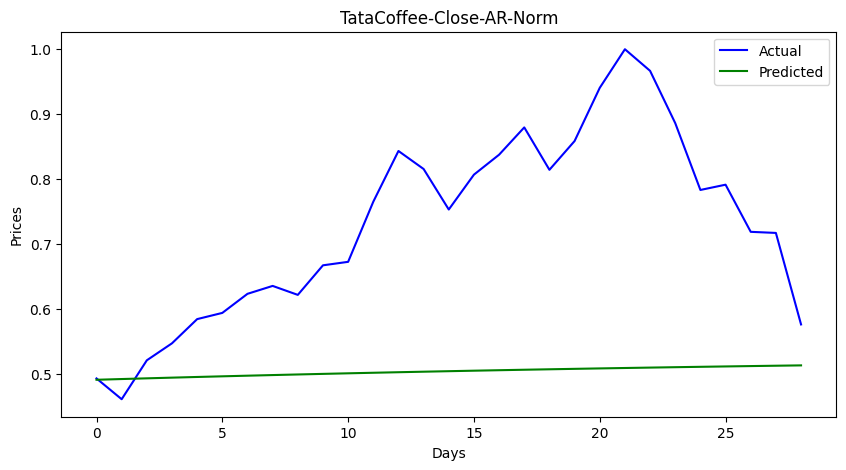

In [15]:
#14.PLOT ACTUAL VS PREDICTED PRICES

from stockFunctions import graph
# from → keyword to import a specific part of a module
# stockFunctions (module) → a custom module containing user-defined stock analysis functions
# import → keyword that loads the specified item
# graph → custom function that plots actual vs predicted values

graph(y_test, y_pred, "Actual", "Predicted", "TataCoffee-Close-AR-Norm", "Days", "Prices")
# graph(...) → calls the custom function to draw the comparison plot
# y_test → the actual test values
# y_pred → the model's predicted values
# "Actual" → label for the actual values line
# "Predicted" → label for the predicted values line
# "TataCoffee-Close-AR-Norm" → title for the plot
# "Days" → label for the x-axis
# "Prices" → label for the y-axis

# This code plots the actual vs predicted "Close" prices from the AutoReg model, letting you visually compare how well the model's 
# forecasts match the real values.

In [16]:
#15.CHECK LENGTH OF SCALED DATA

len(data1)
# len(...) → built-in function that returns the number of elements
# data1 → the full scaled "Close" price array

# This code returns the total number of rows in data1, confirming the full dataset size.

144

In [17]:
#16.DISPLAY TEST TARGET DATA

y_test
# y_test → the variable holding the actual "Close" price values reserved for testing
# (no method/operator) → simply displays y_test's contents directly in the notebook output

# This code prints out y_test — the actual target values used to evaluate the model's predictions.

array([[0.4931024 ],
       [0.46109991],
       [0.5210234 ],
       [0.5471965 ],
       [0.58444467],
       [0.59400402],
       [0.62338188],
       [0.63556554],
       [0.62175072],
       [0.66727535],
       [0.67263908],
       [0.76520406],
       [0.84331426],
       [0.81556821],
       [0.75319601],
       [0.80688265],
       [0.83760161],
       [0.87962945],
       [0.81434354],
       [0.85864447],
       [0.94054348],
       [1.        ],
       [0.96671625],
       [0.88619137],
       [0.78330247],
       [0.79141967],
       [0.71883606],
       [0.71714276],
       [0.5762395 ]])

In [18]:
#17.CONVERT SCALED TEST DATA BACK TO A LABELED TABLE

from stockFunctions import conversionSingle
# from → keyword to import a specific part of a module
# stockFunctions (module) → a custom module containing user-defined stock analysis functions
# import → keyword that loads the specified item
# conversionSingle → custom function that converts a scaled array back into a labeled DataFrame

aTestNormTable = conversionSingle(y_test, [column])
# aTestNormTable → variable name storing the resulting labeled table
# = → assignment operator
# conversionSingle(...) → calls the custom function to perform the conversion
# y_test → the scaled test data being converted
# [column] → list containing the column name ("Close") to label the resulting table

# This code converts the scaled y_test array into a labeled DataFrame (aTestNormTable) with the "Close" column name, making 
# it easier to read and compare.

In [19]:
#18.DISPLAY LABELED TEST TABLE

aTestNormTable
# aTestNormTable → the DataFrame variable holding the labeled, scaled test data
# (no method/operator) → simply displays the DataFrame's contents directly in the notebook output

# This code prints out aTestNormTable — the "Close" test values presented as a readable, labeled table.

,Close
0,0.493102
1,0.4611
2,0.521023
3,0.547197
4,0.584445
5,0.594004
6,0.623382
7,0.635566
8,0.621751
9,0.667275


In [20]:
#19.REVERSE MIN-MAX SCALING TO GET ORIGINAL TEST PRICES

actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
# actual_stock_price_test_ori → variable name storing the un-scaled (original-range) test prices
# = → assignment operator
# Ms → the MinMaxScaler object created earlier
# . → dot operator used to access a method belonging to the object
# inverse_transform(...) → method that reverses the scaling, converting values back to their original price range
# aTestNormTable → the labeled, scaled test data being converted back

# This code reverses the Min-Max scaling on aTestNormTable, restoring the actual test "Close" prices to their real dollar-value range.

In [21]:
#20.DISPLAY ORIGINAL-SCALE TEST PRICES

actual_stock_price_test_ori
# actual_stock_price_test_ori → the array holding the un-scaled (original-range) actual test prices
# (no method/operator) → simply displays its contents directly in the notebook output

# This code prints out actual_stock_price_test_ori — the real "Close" price values (restored from the 0–1 scaled range) used for testing.

array([[3119.6940918 ],
       [3095.80200195],
       [3140.5390625 ],
       [3160.07910156],
       [3187.88745117],
       [3195.02416992],
       [3216.95678711],
       [3226.05273437],
       [3215.73901367],
       [3249.72631836],
       [3253.73071289],
       [3322.83691406],
       [3381.15161133],
       [3360.43725586],
       [3313.87207031],
       [3353.95288086],
       [3376.88671875],
       [3408.26342773],
       [3359.52294922],
       [3392.59667969],
       [3453.73999023],
       [3498.12841797],
       [3473.27978516],
       [3413.16235352],
       [3336.34863281],
       [3342.40869141],
       [3288.2199707 ],
       [3286.95581055],
       [3181.76171875]])

In [22]:
#21.CONVERT ORIGINAL-SCALE TEST PRICES INTO A LABELED TABLE

actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])
# actual_stock_price_test_oriA → variable name storing the resulting labeled table
# = → assignment operator
# conversionSingle(...) → calls the custom function to perform the conversion
# actual_stock_price_test_ori → the un-scaled (original-range) test price array being converted
# [column] → list containing the column name ("Close") to label the resulting table

# This code converts the original-scale test prices into a labeled DataFrame (actual_stock_price_test_oriA) with the "Close" column name, 
# making it easier to read and compare.

In [23]:
#22.DISPLAY LABELED ORIGINAL-SCALE TEST TABLE

actual_stock_price_test_oriA
# actual_stock_price_test_oriA → the DataFrame variable holding the labeled, original-scale test data
# (no method/operator) → simply displays the DataFrame's contents directly in the notebook output

# This code prints out actual_stock_price_test_oriA — the real "Close" test prices presented as a readable, labeled table.

,Close
0,3119.694092
1,3095.802002
2,3140.539062
3,3160.079102
4,3187.887451
5,3195.02417
6,3216.956787
7,3226.052734
8,3215.739014
9,3249.726318


In [24]:
#23.CONVERT SCALED TEST DATA BACK TO ORIGINAL LABELED PRICES (FULL PIPELINE)

from stockFunctions import conversionSingle
# from → keyword to import a specific part of a module
# stockFunctions (module) → a custom module containing user-defined stock analysis functions
# import → keyword that loads the specified item
# conversionSingle → custom function that converts a scaled array back into a labeled DataFrame

aTestNormTable = conversionSingle(y_test, [column])
# aTestNormTable → variable name storing the labeled, scaled test table
# = → assignment operator
# conversionSingle(...) → calls the custom function to perform the conversion
# y_test → the scaled test data being converted
# [column] → list containing the column name ("Close") to label the resulting table

actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
# actual_stock_price_test_ori → variable name storing the un-scaled (original-range) test prices
# = → assignment operator
# Ms → the MinMaxScaler object created earlier
# . → dot operator used to access a method belonging to the object
# inverse_transform(...) → method that reverses the scaling, converting values back to their original price range
# aTestNormTable → the labeled, scaled test data being converted back

actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])
# actual_stock_price_test_oriA → variable name storing the resulting labeled table
# = → assignment operator
# conversionSingle(...) → calls the custom function to perform the conversion
# actual_stock_price_test_ori → the un-scaled (original-range) test price array being converted
# [column] → list containing the column name ("Close") to label the resulting table

# This code takes the scaled test values (y_test), converts them into a labeled table, reverses the Min-Max scaling to restore original prices, 
# then re-labels that restored data into a final readable DataFrame (actual_stock_price_test_oriA).

In [25]:
#24.CONVERT SCALED PREDICTED DATA BACK TO ORIGINAL LABELED PRICES (FULL PIPELINE)

from stockFunctions import conversionSingle
# from → keyword to import a specific part of a module
# stockFunctions (module) → a custom module containing user-defined stock analysis functions
# import → keyword that loads the specified item
# conversionSingle → custom function that converts a scaled array back into a labeled DataFrame

pTestNormTable = conversionSingle(y_pred, [column])
# pTestNormTable → variable name storing the labeled, scaled predicted table
# = → assignment operator
# conversionSingle(...) → calls the custom function to perform the conversion
# y_pred → the scaled predicted values being converted
# [column] → list containing the column name ("Close") to label the resulting table

predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
# predicted_stock_price_test_ori → variable name storing the un-scaled (original-range) predicted prices
# = → assignment operator
# Ms → the MinMaxScaler object created earlier
# . → dot operator used to access a method belonging to the object
# inverse_transform(...) → method that reverses the scaling, converting values back to their original price range
# pTestNormTable → the labeled, scaled predicted data being converted back

predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, [column])
# predicted_stock_price_test_oriP → variable name storing the resulting labeled table
# = → assignment operator
# conversionSingle(...) → calls the custom function to perform the conversion
# predicted_stock_price_test_ori → the un-scaled (original-range) predicted price array being converted
# [column] → list containing the column name ("Close") to label the resulting table

# This code takes the scaled predicted values (y_pred), converts them into a labeled table, reverses the Min-Max scaling to restore original prices, 
# then re-labels that restored data into a final readable DataFrame (predicted_stock_price_test_oriP).

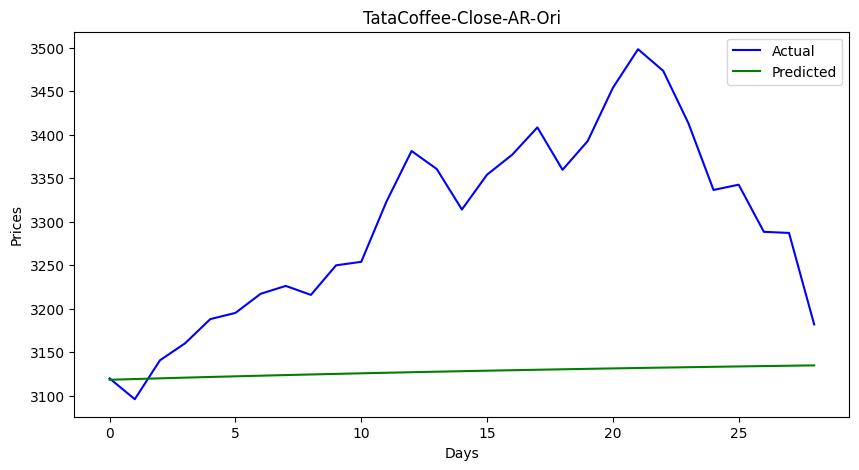

In [26]:
#25.PLOT ACTUAL VS PREDICTED PRICES (ORIGINAL SCALE)

from stockFunctions import graph
# from → keyword to import a specific part of a module
# stockFunctions (module) → a custom module containing user-defined stock analysis functions
# import → keyword that loads the specified item
# graph → custom function that plots actual vs predicted values

graph(actual_stock_price_test_oriA, predicted_stock_price_test_oriP, "Actual", "Predicted", "TataCoffee-Close-AR-Ori", "Days", "Prices")
# graph(...) → calls the custom function to draw the comparison plot
# actual_stock_price_test_oriA → the real (original-scale) actual "Close" prices
# predicted_stock_price_test_oriP → the real (original-scale) predicted "Close" prices
# "Actual" → label for the actual values line
# "Predicted" → label for the predicted values line
# "TataCoffee-Close-AR-Ori" → title for the plot
# "Days" → label for the x-axis
# "Prices" → label for the y-axis

# This code plots the actual vs predicted "Close" prices in their original (real-dollar) scale, letting you visually compare the 
# AutoReg model's forecasts against real values.

In [27]:
#26.EVALUATE MODEL USING RMSE/MAPE (ORIGINAL SCALE)

from stockFunctions import rmsemape
# from → keyword to import a specific part of a module
# stockFunctions (module) → a custom module containing user-defined stock analysis functions
# import → keyword that loads the specified item
# rmsemape → custom function that calculates RMSE and MAPE error metrics

rmsemape(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)
# rmsemape(...) → calls the custom function to calculate and print RMSE/MAPE
# actual_stock_price_test_oriA → the real (original-scale) actual "Close" prices
# predicted_stock_price_test_oriP → the real (original-scale) predicted "Close" prices

# This code calculates and prints the RMSE and MAPE error metrics between the actual and predicted "Close" prices, 
# now in their original (real-dollar) scale for meaningful interpretation.

RMSE-Testset: 198.50660528581872
maPe-Testset: 0.0508856928664217


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [28]:
#27.FORECAST FUTURE VALUES BEYOND THE DATASET

forecast = model_fit.predict(len(data1), len(data1)+3)
# forecast → variable name storing the future predicted values
# = → assignment operator
# model_fit → the trained AutoReg model
# . → dot operator used to access a method belonging to the object
# predict(...) → method that generates forecasted values
# len(data1) → the starting index for prediction (right after all existing data ends)
# len(data1)+3 → the ending index for prediction (3 steps beyond the end of the dataset)

# This code uses the trained AutoReg model to forecast 4 new future "Close" price values beyond the existing dataset.

In [29]:
#28.DISPLAY FORECASTED VALUES

forecast
# forecast → the variable holding the future predicted "Close" price values
# (no method/operator) → simply displays forecast's contents directly in the notebook output

# This code prints out forecast — the model's predicted "Close" prices for the days beyond the existing dataset.

array([0.51371949, 0.51421779, 0.51470192, 0.51517226])

In [30]:
#29.CONVERT FORECASTED VALUES BACK TO ORIGINAL LABELED PRICES (FULL PIPELINE)

from stockFunctions import conversionSingle
# from → keyword to import a specific part of a module
# stockFunctions (module) → a custom module containing user-defined stock analysis functions
# import → keyword that loads the specified item
# conversionSingle → custom function that converts a scaled array back into a labeled DataFrame

fTestNormTable = conversionSingle(forecast, ["Closefore"])
# fTestNormTable → variable name storing the labeled, scaled forecast table
# = → assignment operator
# conversionSingle(...) → calls the custom function to perform the conversion
# forecast → the scaled forecasted values being converted
# ["Closefore"] → list containing the label name for the forecasted column

forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
# forecast_stock_price_test_ori → variable name storing the un-scaled (original-range) forecasted prices
# = → assignment operator
# Ms → the MinMaxScaler object created earlier
# . → dot operator used to access a method belonging to the object
# inverse_transform(...) → method that reverses the scaling, converting values back to their original price range
# fTestNormTable → the labeled, scaled forecast data being converted back

forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])
# forecast_stock_price_test_oriF → variable name storing the resulting labeled table
# = → assignment operator
# conversionSingle(...) → calls the custom function to perform the conversion
# forecast_stock_price_test_ori → the un-scaled (original-range) forecast array being converted
# ["Closefore"] → list containing the label name for the forecasted column

# This code takes the scaled forecast values, converts them into a labeled table, reverses the Min-Max scaling to restore original prices, 
# then re-labels that restored data into a final readable DataFrame (forecast_stock_price_test_oriF).

In [31]:
#30.DISPLAY LABELED FORECASTED PRICES

forecast_stock_price_test_oriF
# forecast_stock_price_test_oriF → the DataFrame variable holding the labeled, original-scale forecasted "Close" prices
# (no method/operator) → simply displays the DataFrame's contents directly in the notebook output

# This code prints out forecast_stock_price_test_oriF — the model's future "Close" price forecasts presented as a readable, labeled table.

,Closefore
0,3135.08618
1,3135.458194
2,3135.819636
3,3136.170779


In [32]:
#31.EXPORT FORECASTED PRICES TO CSV FILE

forecast_stock_price_test_oriF.to_csv("CloseAR.csv", index=False)
# forecast_stock_price_test_oriF → the DataFrame holding the labeled, original-scale forecasted prices
# . → dot operator used to access a method belonging to the object
# to_csv(...) → DataFrame method that saves the data as a CSV file
# "CloseAR.csv" → the filename the data will be saved as
# index=False → parameter that excludes the DataFrame's row index from being written to the file

# This code exports forecast_stock_price_test_oriF to a CSV file named "CloseAR.csv", without including the row index, saving the 
# forecasted "Close" prices for later use.

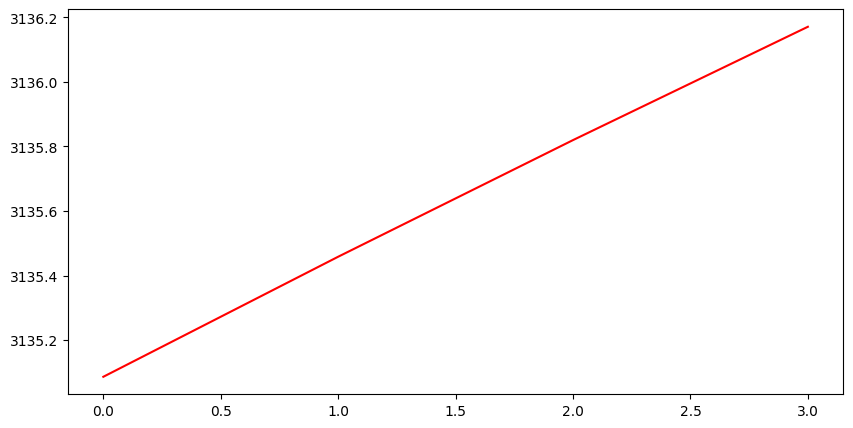

In [33]:
#32.PLOT ACTUAL (RECENT WINDOW) VS FORECASTED PRICES

import matplotlib.pyplot as plt
# import → keyword to load a full module
# matplotlib.pyplot (module) → matplotlib's plotting interface, used to draw charts
# as → keyword used to assign an alias
# plt → alias name assigned to matplotlib.pyplot

plt.figure(figsize=(10,5))
# plt.figure(...) → creates a new figure/canvas for plotting
# figsize=(10,5) → parameter setting the figure's width and height in inches

plt.plot(actual_stock_price_test_oriA[116:145], color='blue', label="Actual")
# plt.plot(...) → draws a line chart
# actual_stock_price_test_oriA[116:145] → slicing operator selecting rows 116 to 144 (a recent window) of the actual prices
# color='blue' → parameter setting the line color to blue
# label="Actual" → parameter setting the legend label to "Actual"

plt.plot(forecast_stock_price_test_oriF, color='red', label="Predicted")
# plt.plot(...) → draws a line chart
# forecast_stock_price_test_oriF → the labeled, original-scale forecasted prices
# color='red' → parameter setting the line color to red
# label="Predicted" → parameter setting the legend label to "Predicted"

# This code plots a recent window (rows 116–144) of the actual "Close" prices in blue alongside the forecasted future prices in red, 
# letting you visually compare how the forecast continues from the actual data.